<h1>IMPORTAÇÕES</h1>


In [60]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

<h1>TRATAMENTO DE DADOS</h1>


In [61]:
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index.freq = "MS"

df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

df.columns = ["ds", "y", "y2", "y3", "y4", "y5"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      45 non-null     datetime64[ns]
 1   y       45 non-null     int64         
 2   y2      45 non-null     int64         
 3   y3      45 non-null     int64         
 4   y4      45 non-null     int64         
 5   y5      45 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 2.2 KB


<h1>PREVISÕES</h1>


<h3>Previsões com train/test</h3>

In [62]:
train = df.iloc[:34]
test = df.iloc[33:]

m = Prophet(growth='flat', seasonality_mode='additive')

m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

10:21:56 - cmdstanpy - INFO - Chain [1] start processing


10:21:56 - cmdstanpy - INFO - Chain [1] done processing


<AxesSubplot:xlabel='ds'>

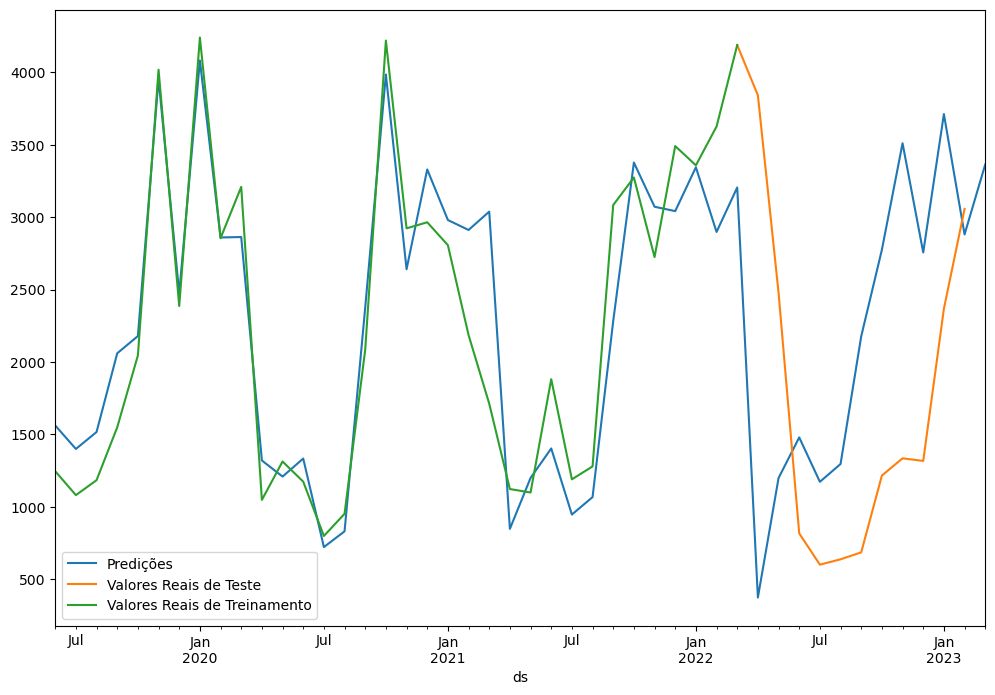

In [63]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

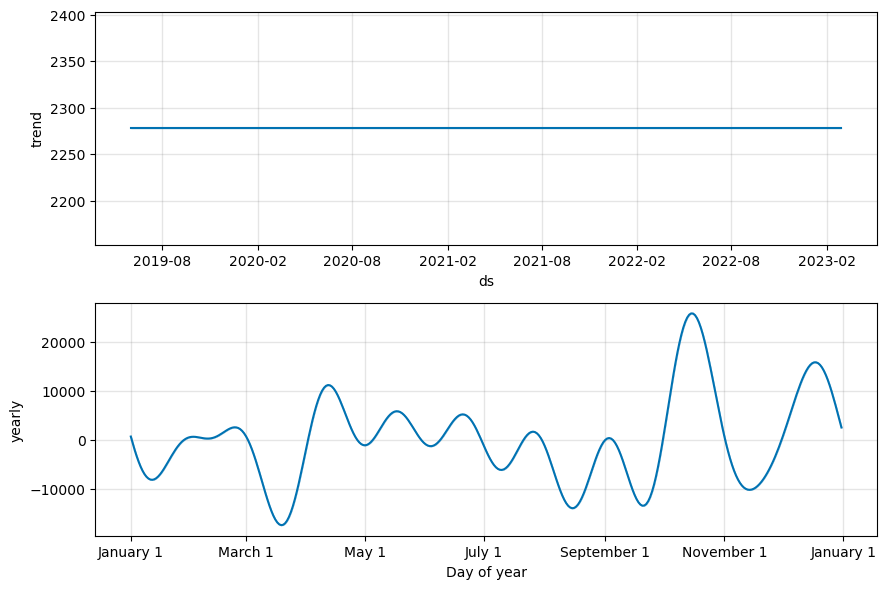

In [64]:
fig = m.plot_components(forecast);

In [65]:
initial = str(24) + ' days'

period = str(24) + ' days'

horizon = str(12) + ' days'

In [66]:
df_cv = cross_validation(m,initial=initial,period=period,horizon=horizon)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/32 [00:00<?, ?it/s]

10:21:56 - cmdstanpy - INFO - Chain [1] start processing
10:21:56 - cmdstanpy - INFO - Chain [1] done processing
10:21:56 - cmdstanpy - INFO - Chain [1] start processing
10:21:56 - cmdstanpy - INFO - Chain [1] done processing
  6%|▋         | 2/32 [00:00<00:02, 10.75it/s]10:21:56 - cmdstanpy - INFO - Chain [1] start processing
10:21:57 - cmdstanpy - INFO - Chain [1] done processing
10:21:57 - cmdstanpy - INFO - Chain [1] start processing
10:21:57 - cmdstanpy - INFO - Chain [1] done processing
 12%|█▎        | 4/32 [00:00<00:05,  5.60it/s]10:21:57 - cmdstanpy - INFO - Chain [1] start processing
10:21:57 - cmdstanpy - INFO - Chain [1] done processing
 16%|█▌        | 5/32 [00:00<00:05,  5.12it/s]10:21:57 - cmdstanpy - INFO - Chain [1] start processing
10:21:57 - cmdstanpy - INFO - Chain [1] done processing
10:21:57 - cmdstanpy - INFO - Chain [1] start processing
10:21:57 - cmdstanpy - INFO - Chain [1] done processing
 22%|██▏       | 7/32 [00:01<00:03,  6.97it/s]10:21:57 - cmdstanpy - IN

In [72]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,5 days,2.391741e+08,15465.255663,6728.416439,3.223665,1.165219,1.268791,0.000000
1,6 days,1.126304e+09,33560.452494,17354.451768,16.280333,0.451319,0.821014,0.000000
2,7 days,7.514292e+08,27412.209251,12001.645935,11.004926,0.512906,0.743179,0.000000
3,8 days,3.764942e+08,19403.458733,6624.934872,5.690729,0.454112,0.604963,0.000000
4,12 days,1.132849e+08,10643.539111,6565.398449,2.745992,0.862747,1.126206,0.066667


<h3>Previsões sem train/test</h3>

In [67]:
m = Prophet()

m.fit(df)

10:22:16 - cmdstanpy - INFO - Chain [1] start processing


10:22:16 - cmdstanpy - INFO - Chain [1] done processing


In [68]:
future = m.make_future_dataframe(periods=12,freq='MS')

forecast = m.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,2528.839035,224.287853,2062.317114,2528.839035,2528.839035,-1419.920352,-1419.920352,-1419.920352,-1419.920352,-1419.920352,-1419.920352,0.0,0.0,0.0,1108.918683
1,2019-07-01,2518.687246,273.617262,2121.901252,2518.687246,2518.687246,-1309.857332,-1309.857332,-1309.857332,-1309.857332,-1309.857332,-1309.857332,0.0,0.0,0.0,1208.829915
2,2019-08-01,2508.197065,651.696848,2408.160451,2508.197065,2508.197065,-978.632312,-978.632312,-978.632312,-978.632312,-978.632312,-978.632312,0.0,0.0,0.0,1529.564752
3,2019-09-01,2497.706883,1068.640053,2860.495218,2497.706883,2497.706883,-546.270052,-546.270052,-546.270052,-546.270052,-546.270052,-546.270052,0.0,0.0,0.0,1951.436831
4,2019-10-01,2487.555095,1274.442967,3132.032489,2487.555095,2487.555095,-322.749157,-322.749157,-322.749157,-322.749157,-322.749157,-322.749157,0.0,0.0,0.0,2164.805937


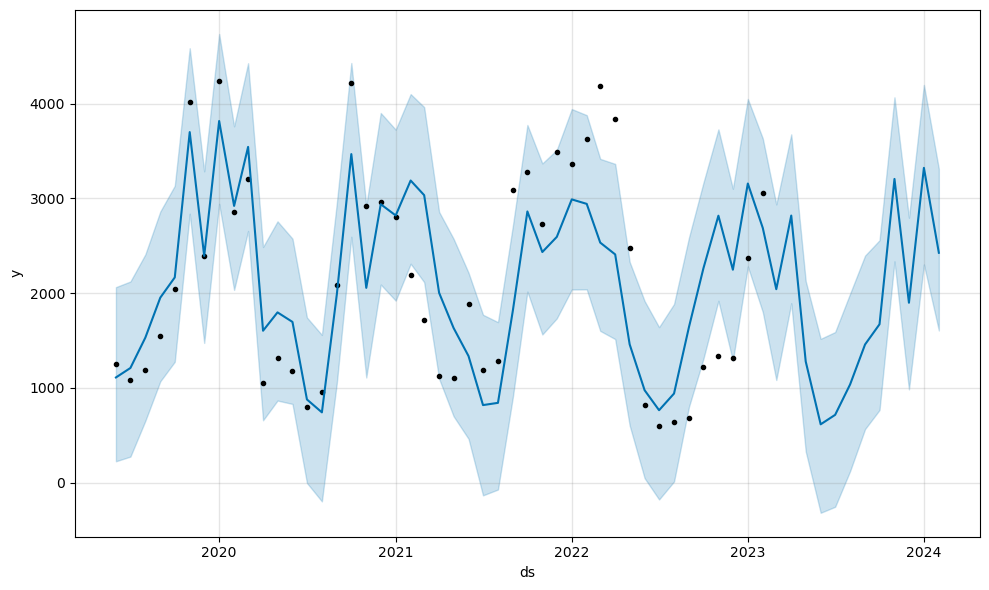

In [69]:
m.plot(forecast);